# Quadratic Discriminant Analysis

In [6]:
# change the directory to the repository
import os
os.chdir(r"C:\Users\mattc\OneDrive\Documents\Data\Apziva\uyBvjh22fVpcb3UX")
os.getcwd()

'C:\\Users\\mattc\\OneDrive\\Documents\\Data\\Apziva\\uyBvjh22fVpcb3UX'

In [7]:
# import all the necessary libraries
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [8]:
# set random state for the notebook
random_state = 42
np.random.seed(random_state)
random.seed(random_state)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


C:\Users\mattc\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
C:\Users\mattc\anaconda3\Lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


Best Parameters:
{'classifier__reg_param': 0.0}
              precision    recall  f1-score   support

           0       1.00      0.14      0.24      7421
           1       0.08      0.99      0.15       579

    accuracy                           0.20      8000
   macro avg       0.54      0.57      0.20      8000
weighted avg       0.93      0.20      0.23      8000



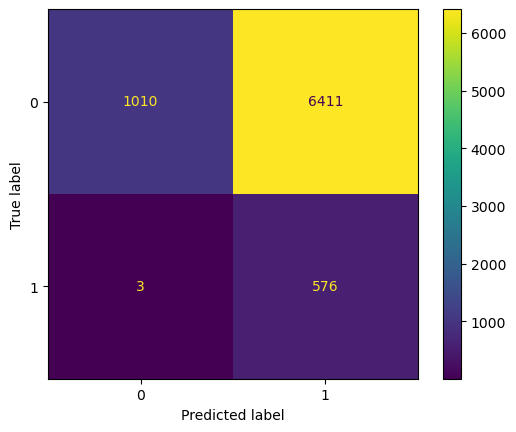

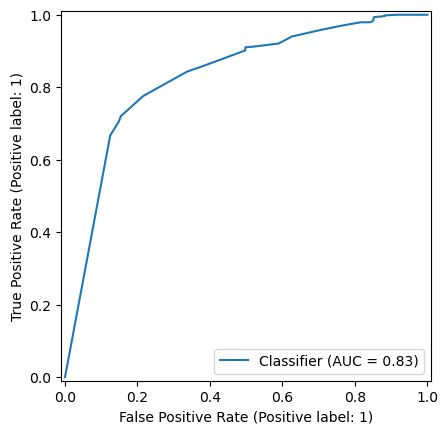

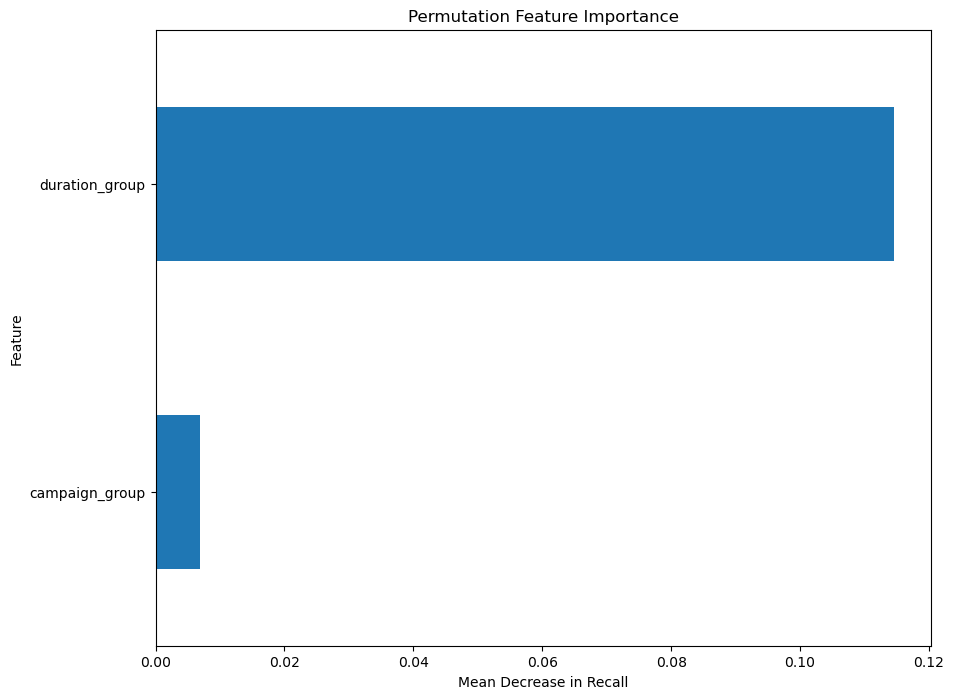

In [56]:
# import the data
data = pd.read_csv("data/processed/processed_data.csv")

# split into x and y
columns_to_exclude=['job', 'age_group', 'education', 'default', 'marital', 'balance_group', 'day_group', 'housing', 'loan', 'contact', 'quarter']
x = data.select_dtypes(include='object').drop(columns=columns_to_exclude)
y = data['target']

# train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state, stratify=y)

# create a list of features 
cat_features = x.select_dtypes(include='object').columns

# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False), cat_features)
    ])

# modelling pipeline
model_pipe = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('classifier', QuadraticDiscriminantAnalysis())
    ])

# hyperparameter options
param_grid = {
    'classifier__reg_param': [0.0, 0.01, 0.05, 0.1, 0.2]
}

# grid search to tune hyperparameters using cross validation
grid = GridSearchCV(
    model_pipe,
    param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

# fitting grid to data
grid.fit(x_train, y_train)

# find the best model and use it to make prediction
best_model = grid.best_estimator_
y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

# display the best parameters
print('Best Parameters:')
print(grid.best_params_)

# show classification report containing detailed metrics
print(classification_report(y_test, y_pred))

# show confusion matrix of predicted data vs actual
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

# display ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.show()

# compare the significance of each feature
result = permutation_importance(
    best_model,
    x_test,
    y_test,
    scoring='recall',
    n_repeats=10,
    random_state=random_state,
    n_jobs=-1
)

# sort into dataframe
feature_importance = pd.DataFrame({
    'feature': x_test.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

# plot feature importances
feature_importance.sort_values('importance').plot(
    x='feature',
    y='importance',
    kind='barh',
    figsize=(10, 8),
    legend=False
)

plt.xlabel('Mean Decrease in Recall')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance')
plt.show()

In [60]:
round(recall_score(y_test, y_pred), 4) * 100

99.48

In [59]:
round(precision_score(y_test, y_pred), 4) * 100

8.24